# Customer Shopping Behavior Analysis
## Phase 1: Data Cleaning & Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Data Loading

The dataset was loaded using pandas. Initial inspection shows the structure of the dataset along with the number of rows and columns.

In [4]:
df = pd.read_csv('C:/Projects/ShoppingAnalysis/data/customer_shopping_behavior.csv')
print("Shape:", df.shape)
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### Data Exploration

Initial exploration was performed to understand the dataset structure, data types, summary statistics, missing values, and duplicate records.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df.duplicated().sum()

0

### Data Cleaning

Column names were standardized, text values were formatted, and duplicate records were removed to ensure consistency and data quality.

In [9]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip().str.title())
df.drop_duplicates(inplace=True)

print("Cleaned! Shape:", df.shape)
print(df.columns.tolist())

Cleaned! Shape: (3900, 18)
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


### Exploratory Data Analysis (EDA)

Visualisations were created to analyze customer demographics and revenue patterns. These include gender distribution, age distribution, and revenue generated by product categories.

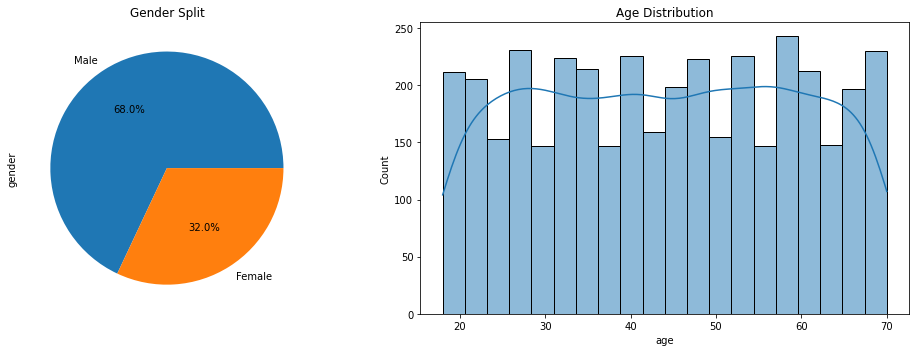

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', title='Gender Split')

sns.histplot(df['age'], bins=20, ax=axes[1], kde=True)
axes[1].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('C:/Projects/ShoppingAnalysis/data/fig_demographics.png')
plt.show()

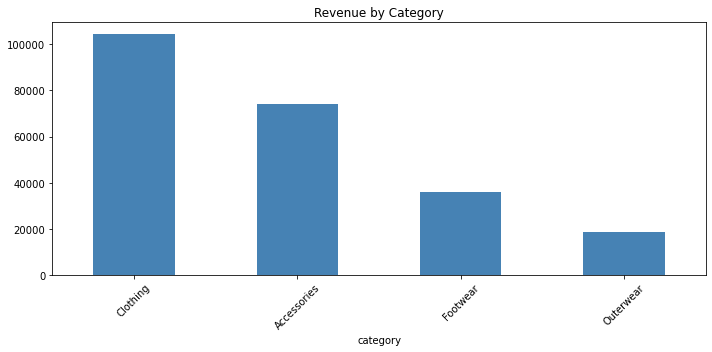

In [12]:
purchase_col = [c for c in df.columns if 'purchase' in c and 'amount' in c][0]

category_revenue = df.groupby('category')[purchase_col].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar', figsize=(10,5), title='Revenue by Category', color='steelblue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('C:/Projects/ShoppingAnalysis/data/fig_category_revenue.png')
plt.show()

### Data Export to MySQL

The cleaned dataset was exported to a MySQL database using SQLAlchemy. A table named 'customer' was created in the 'customer_behavior' database for further analysis using SQL.

In [16]:
from sqlalchemy import create_engine

username = "root"
password = "dhruwinchess"
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql('customer', engine, if_exists='replace', index=False)

print("Data loaded into MySQL successfully!")

Data loaded into MySQL successfully!


In [18]:
df.to_csv('C:/Projects/ShoppingAnalysis/data/customer_shopping_cleaned.csv', index=False)
print("Cleaned CSV saved!")

Cleaned CSV saved!
